In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import zipfile
from google.colab import drive

In [2]:
DRIVE_ZIP_PATH = '/content/drive/MyDrive/archive.zip' # Path to your zip file on Google Drive
EXTRACT_PATH = '/content/dataset'                    # Local Colab path to unzip data
BATCH_SIZE = 4                                       # Batch size for testing the loader

# --- 2. Data Extraction Function ---

def extract_data(zip_path, extract_path):
    """
    Mounts Google Drive and extracts the dataset zip file to the local
    Colab runtime environment for faster access.
    """
    try:
        # Mount Google Drive
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")

        # Check if zip file exists
        if not os.path.exists(zip_path):
            print(f"ERROR: Zip file not found at {zip_path}")
            print("Please check the path in DRIVE_ZIP_PATH.")
            return False

        # Extract data
        if not os.path.exists(extract_path) or not os.listdir(extract_path):
            print(f"Extracting dataset from {zip_path} to {extract_path}...")
            os.makedirs(extract_path, exist_ok=True)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
            print("Extraction complete.")
        else:
            print("Dataset already extracted.")
        return True
    except Exception as e:
        print(f"An error occurred during extraction: {e}")
        return False

In [3]:
# --- 3. Custom PyTorch Dataset Class ---

class DeepGlobeDataset(Dataset):
    """
    Custom Dataset for DeepGlobe. Loads satellite images and converts
    RGB masks to single-channel integer masks.
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Find all satellite images, assuming they are in the root of image_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('_sat.jpg')])

        # Define the critical mapping from RGB color to Class ID
        self.rgb_to_id = {
            (0, 255, 255): 0,   # urban_land
            (255, 255, 0): 1,   # agriculture_land
            (255, 0, 255): 2,   # rangeland
            (0, 255, 0): 3,     # forest_land
            (0, 0, 255): 4,     # water
            (255, 255, 255): 5, # barren_land
            (0, 0, 0): 6        # unknown
        }

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and mask paths
        img_name = self.images[idx]
        mask_name = img_name.replace('_sat.jpg', '_mask.png')
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask_rgb = Image.open(mask_path).convert("RGB")

        image_np = np.array(image)
        mask_rgb_np = np.array(mask_rgb)

        # --- Core Conversion Logic ---
        # Create a single-channel integer mask, initialized to 'unknown' (ID 6)
        mask_int = np.full((mask_rgb_np.shape[0], mask_rgb_np.shape[1]),
                           fill_value=6, dtype=np.int64)

        # Map each color pixel to its corresponding class ID
        for rgb_val, class_id in self.rgb_to_id.items():
            target_pixels = np.all(mask_rgb_np == rgb_val, axis=-1)
            mask_int[target_pixels] = class_id

        # Apply transforms (e.g., augmentations) if provided
        if self.transform:
            augmented = self.transform(image=image_np, mask=mask_int)
            image_np = augmented['image']
            mask_int = augmented['mask']

        # Convert to Tensors
        # Normalize image to [0, 1] and set format to [C, H, W]
        image_tensor = torch.from_numpy(image_np.transpose((2, 0, 1))).float() / 255.0
        # Convert mask to LongTensor [H, W]
        mask_tensor = torch.from_numpy(mask_int).long()

        return image_tensor, mask_tensor

In [5]:
# --- 4. Verification Functions ---

def verify_mask_conversion(mask_dir):
    """
    Loads one mask and plots the original RGB vs. the processed integer
    mask to visually verify the conversion.
    """
    print("\n--- Verifying Mask Conversion ---")
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('_mask.png')]
    if not mask_files:
        print(f"ERROR: No mask files found in {mask_dir}")
        return

    test_mask_name = mask_files[0]
    mask_path = os.path.join(mask_dir, test_mask_name)

    # Load original RGB mask
    mask_rgb_np = np.array(Image.open(mask_path).convert("RGB"))

    # --- Re-run the conversion logic manually ---
    mask_int_np = np.full(mask_rgb_np.shape[:2], fill_value=6, dtype=np.int64)
    rgb_to_id_map = {
        (0, 255, 255): 0, (255, 255, 0): 1, (255, 0, 255): 2,
        (0, 255, 0): 3, (0, 0, 255): 4, (255, 255, 255): 5, (0, 0, 0): 6
    }
    for rgb_val, class_id in rgb_to_id_map.items():
        target_pixels = np.all(mask_rgb_np == rgb_val, axis=-1)
        mask_int_np[target_pixels] = class_id

    # --- Plotting ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(mask_rgb_np)
    ax[0].set_title(f"Original RGB Mask\nShape: {mask_rgb_np.shape}")
    ax[0].axis('off')

    im = ax[1].imshow(mask_int_np, cmap='tab10', vmin=0, vmax=6)
    ax[1].set_title(f"Processed Integer Mask\nShape: {mask_int_np.shape}")
    ax[1].axis('off')

    fig.colorbar(im, ax=ax[1], ticks=range(7), orientation='vertical')
    plt.tight_layout()
    plt.savefig("mask_conversion_check.png")
    print("Verification plot saved to 'mask_conversion_check.png'")
    plt.show()

In [6]:
def verify_dataloader(dataset):
    """
    Checks the output of the DataLoader to confirm batch shapes and data types.
    """
    print("\n--- Verifying DataLoader ---")
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    images, masks = next(iter(loader))

    print(f"Images batch shape: {images.shape}")
    print(f"Images batch dtype: {images.dtype}")
    print(f"Images min/max:   {images.min()}, {images.max()}")
    print(f"Masks batch shape:  {masks.shape}")
    print(f"Masks batch dtype:  {masks.dtype}")
    print(f"Unique values in masks: {torch.unique(masks)}")
    print("DataLoader check passed.")

Mounted at /content/drive
Google Drive mounted successfully.
Extracting dataset from /content/drive/MyDrive/archive.zip to /content/dataset...
Extraction complete.

--- Verifying Mask Conversion ---
Verification plot saved to 'mask_conversion_check.png'


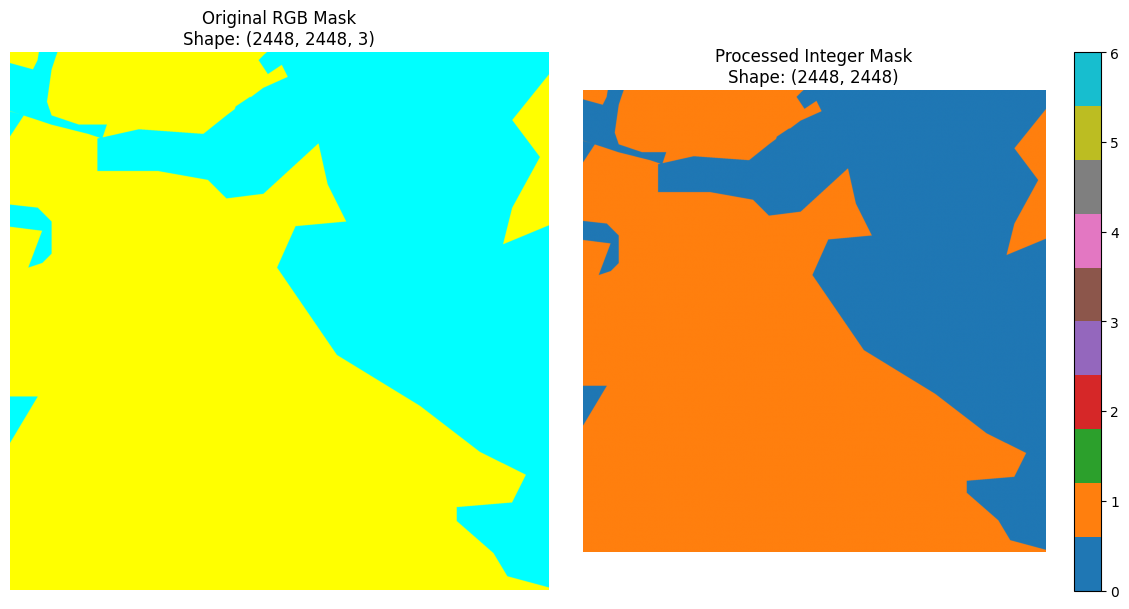


--- Verifying DataLoader ---
Images batch shape: torch.Size([4, 3, 2448, 2448])
Images batch dtype: torch.float32
Images min/max:   0.0, 1.0
Masks batch shape:  torch.Size([4, 2448, 2448])
Masks batch dtype:  torch.int64
Unique values in masks: tensor([0, 1, 3, 4, 5, 6])
DataLoader check passed.

Preprocessing pipeline setup and verification complete.


In [7]:
# --- 5. Main Execution Block ---

if __name__ == "__main__":
    # This block will run when you execute the cell in Colab

    # Step 1: Extract the data
    if extract_data(DRIVE_ZIP_PATH, EXTRACT_PATH):

        # Step 2: Define dataset paths (adjust if your zip file has a different structure)
        # Assumes data is in /content/dataset/train/
        TRAIN_DIR = os.path.join(EXTRACT_PATH, "train")

        # Check if the 'train' directory exists
        if not os.path.exists(TRAIN_DIR):
            print(f"ERROR: 'train' directory not found in {EXTRACT_PATH}")
            print("Please check your zip file structure and update TRAIN_DIR.")
        else:
            # In the DeepGlobe dataset, images and masks are in the same folder
            TRAIN_IMG_DIR = TRAIN_DIR
            TRAIN_MASK_DIR = TRAIN_DIR

            # Step 3: Verify the mask conversion
            verify_mask_conversion(TRAIN_MASK_DIR)

            # Step 4: Verify the DataLoader
            train_dataset = DeepGlobeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR)

            if len(train_dataset) > 0:
                verify_dataloader(train_dataset)
                print("\nPreprocessing pipeline setup and verification complete.")
            else:
                print(f"ERROR: No images found in {TRAIN_IMG_DIR}. Cannot verify DataLoader.")


--- Creating Presentation Visualization ---

Visualization saved to 'BTP_Review_Visualization.png'


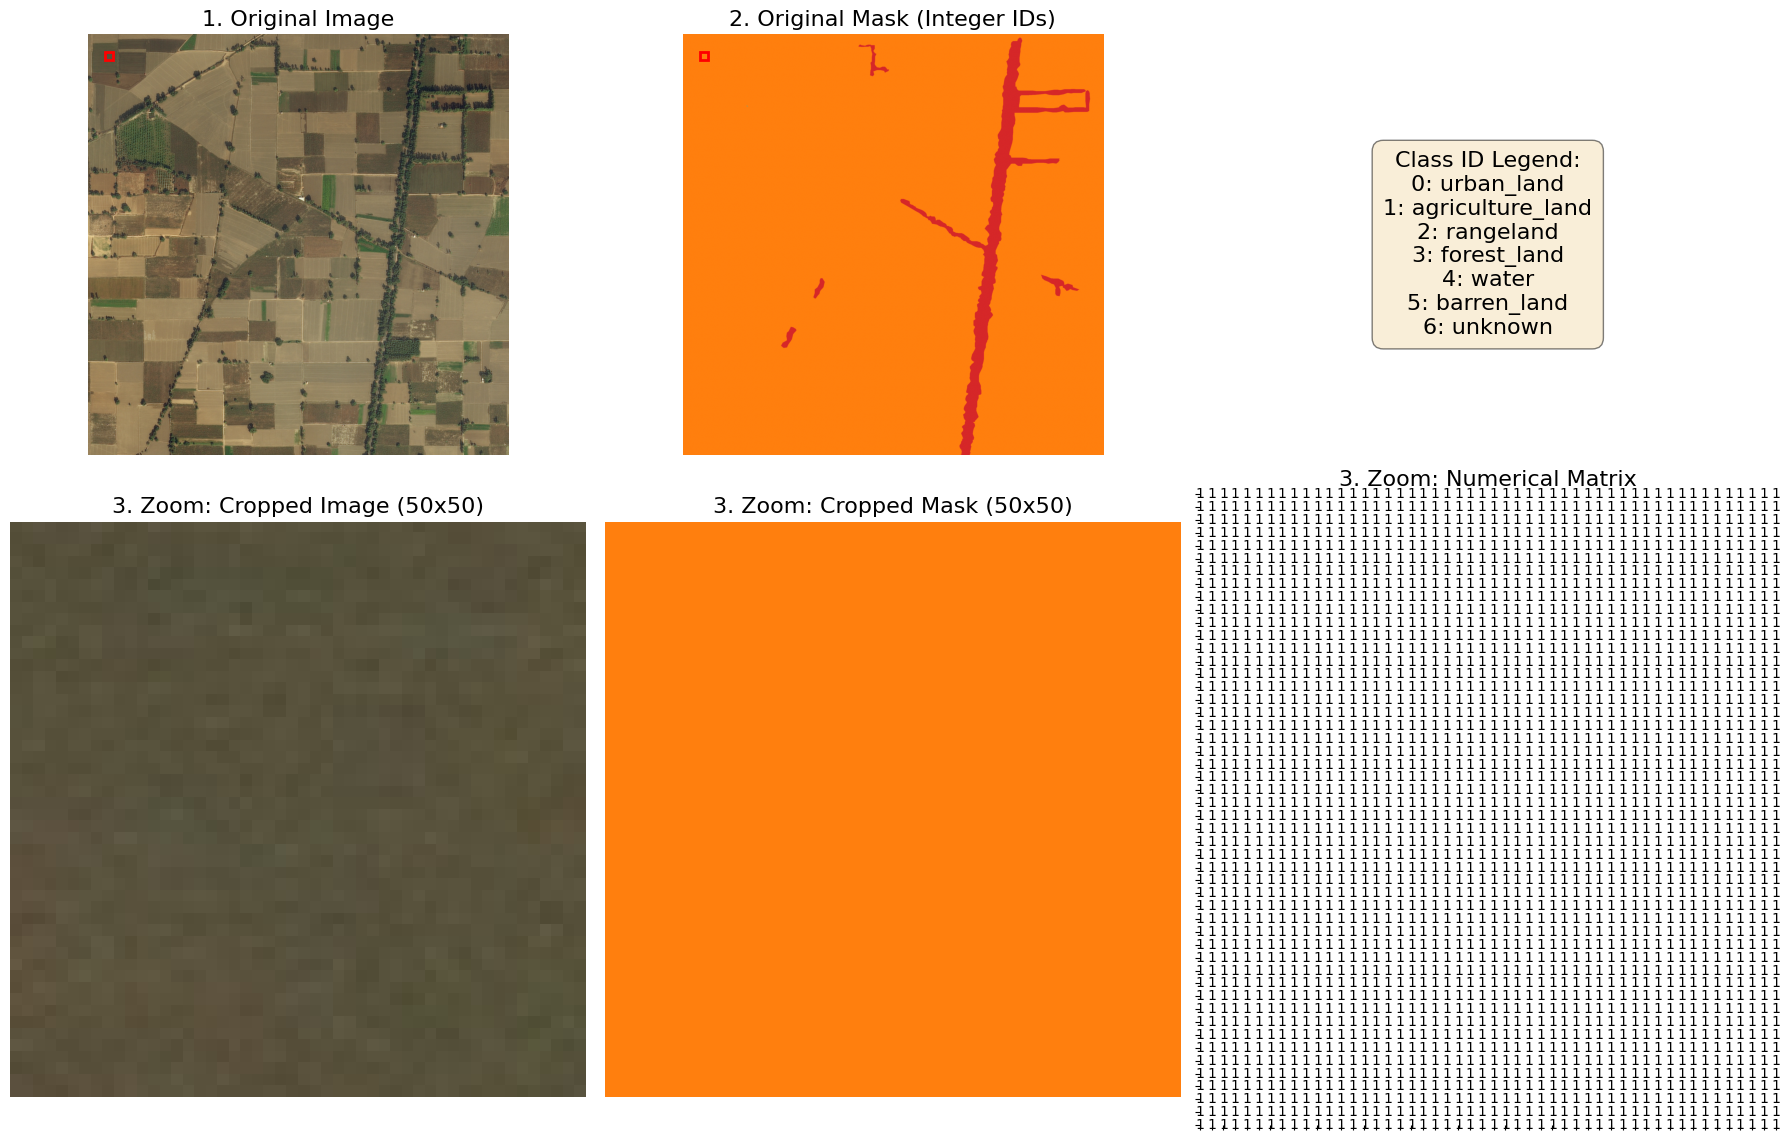

In [8]:
import matplotlib.gridspec as gridspec

# Define a reverse mapping from ID to Class Name for the legend
id_to_name = {
    0: "urban_land",
    1: "agriculture_land",
    2: "rangeland",
    3: "forest_land",
    4: "water",
    5: "barren_land",
    6: "unknown"
}


def create_presentation_visual():
    """
    Generates a multi-panel visualization suitable for a presentation,
    showing an image, its mask, a zoomed-in section of both, and a
    numerical representation of the zoomed mask.
    """
    print("\n--- Creating Presentation Visualization ---")
    try:
        # Load one example from the dataset
        train_dataset = DeepGlobeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR)
        if len(train_dataset) == 0:
            print("ERROR: Dataset is empty. Cannot create visualization.")
            return

        image_tensor, mask_tensor = train_dataset[0] # Get the first sample

        # Convert tensors to numpy arrays for plotting
        image_np = image_tensor.permute(1, 2, 0).numpy() # Change from [C, H, W] to [H, W, C]
        mask_int = mask_tensor.numpy()

        # Define crop size and coordinates (adjust as needed)
        CROP_SIZE = 50
        start_row = 100 # Example start row
        start_col = 100 # Example start column
        end_row = start_row + CROP_SIZE
        end_col = start_col + CROP_SIZE

        # Ensure crop is within bounds
        if end_row > image_np.shape[0] or end_col > image_np.shape[1]:
             print(f"ERROR: Crop area is out of bounds. Image shape: {image_np.shape[:2]}")
             return

        # Crop the image and mask
        cropped_image = image_np[start_row:end_row, start_col:end_col]
        cropped_int = mask_int[start_row:end_row, start_col:end_col]

        # Setup the figure and grid layout
        fig = plt.figure(figsize=(18, 12))
        gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1, 1.5], width_ratios=[1, 1, 1])

        # Panel 1: Original Image
        ax_img = fig.add_subplot(gs[0, 0])
        ax_img.imshow(image_np)
        ax_img.set_title('1. Original Image', fontsize=16)
        ax_img.axis('off')

        # Panel 2: Original Mask
        ax_mask = fig.add_subplot(gs[0, 1])
        # Use a colormap that clearly distinguishes classes
        im_mask = ax_mask.imshow(mask_int, cmap='tab10', vmin=0, vmax=6)
        ax_mask.set_title('2. Original Mask (Integer IDs)', fontsize=16)
        ax_mask.axis('off')

        # Panel 3: Zoomed Image
        ax_zoom_img = fig.add_subplot(gs[1, 0])
        ax_zoom_img.imshow(cropped_image)
        ax_zoom_img.set_title(f'3. Zoom: Cropped Image ({CROP_SIZE}x{CROP_SIZE})', fontsize=16)
        ax_zoom_img.axis('off')
        # Add a rectangle to the original image to show the zoomed area
        rect = plt.Rectangle((start_col, start_row), CROP_SIZE, CROP_SIZE,
                             linewidth=2, edgecolor='r', facecolor='none')
        ax_img.add_patch(rect)


        # Panel 4: Zoomed Mask
        ax_zoom_mask = fig.add_subplot(gs[1, 1])
        im_zoom_mask = ax_zoom_mask.imshow(cropped_int, cmap='tab10', vmin=0, vmax=6)
        ax_zoom_mask.set_title(f'3. Zoom: Cropped Mask ({CROP_SIZE}x{CROP_SIZE})', fontsize=16)
        ax_zoom_mask.axis('off')
        # Add a rectangle to the original mask to show the zoomed area
        rect_mask = plt.Rectangle((start_col, start_row), CROP_SIZE, CROP_SIZE,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax_mask.add_patch(rect_mask)


        # Panel 5: Numerical Matrix of Zoomed Mask
        ax_matrix = fig.add_subplot(gs[1, 2])
        ax_matrix.set_title(f'3. Zoom: Numerical Matrix', fontsize=16)
        for i in range(CROP_SIZE):
            for j in range(CROP_SIZE):
                ax_matrix.text(j, i, str(cropped_int[i, j]), ha="center", va="center", color="black", fontsize=10)
        ax_matrix.set_xticks(np.arange(CROP_SIZE)), ax_matrix.set_yticks(np.arange(CROP_SIZE))
        ax_matrix.set_xticklabels([]), ax_matrix.set_yticklabels([])
        ax_matrix.grid(which="both", color='w', linestyle='-', linewidth=2)
        ax_matrix.set_frame_on(False)

        # Legend
        legend_text = "Class ID Legend:\n" + "\n".join([f"{k}: {v}" for k, v in id_to_name.items()])
        ax_legend = fig.add_subplot(gs[0, 2]) # Adjusted position for legend
        ax_legend.text(0.5, 0.5, legend_text, ha='center', va='center', fontsize=16,
                       bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5))
        ax_legend.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig("BTP_Review_Visualization.png", dpi=150)
        print("\nVisualization saved to 'BTP_Review_Visualization.png'")
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- 5. Run the Visualization ---
if __name__ == "__main__":
    create_presentation_visual()